**B. KARAKTERISTIK DATA**

---



In [ ]:
import pandas as pd

df = pd.read_csv('StudentPerformanceFactors.csv')

In [ ]:
df.head(5)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [ ]:
df.dtypes

,0
Hours_Studied,int64
Attendance,int64
Parental_Involvement,object
Access_to_Resources,object
Extracurricular_Activities,object
Sleep_Hours,int64
Previous_Scores,int64
Motivation_Level,object
Internet_Access,object
Tutoring_Sessions,int64


**C. PREPROCESSING DATA**

---



1\. Data Cleaning

a. Membersihkan Nilai Null

In [ ]:
df_count = len(df)

col_null = [col_name for col_name in df.columns if df[col_name].isnull().any()]

for column in col_null:
    nulls_count = df[column].isnull().sum()

    print("=====================================================")
    print("")
    print(f"-- Kolom {column} --")
    print("")
    print(f"Jumlah Null: {nulls_count}")
    print(f"Persentase Null: {nulls_count / df_count * 100:.2f}%")
    print(f"Nilai unik: {df[column].dropna().unique()}")
    print("")
    print("=====================================================")


-- Kolom Teacher_Quality --

Jumlah Null: 78
Persentase Null: 1.18%
Nilai unik: ['Medium' 'High' 'Low']


-- Kolom Parental_Education_Level --

Jumlah Null: 90
Persentase Null: 1.36%
Nilai unik: ['High School' 'College' 'Postgraduate']


-- Kolom Distance_from_Home --

Jumlah Null: 67
Persentase Null: 1.01%
Nilai unik: ['Near' 'Moderate' 'Far']



In [ ]:
df['Teacher_Quality_Index'] = df['Teacher_Quality'].map({'Low': 1, 'Medium': 2, 'High': 3})
df['Parental_Education_Level_Index'] = df['Parental_Education_Level'].map({'High School': 1, 'College': 2, 'Post Graduate': 3})
df['Distance_from_Home_Index'] = df['Distance_from_Home'].map({'Near': 1, 'Moderate': 2, 'Far': 3})

df = df.drop(columns=["Teacher_Quality", "Parental_Education_Level", "Distance_from_Home"])
df.head(5)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Gender,Exam_Score,Teacher_Quality_Index,Parental_Education_Level_Index,Distance_from_Home_Index
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Public,Positive,3,No,Male,67,2.0,1.0,1.0
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Public,Negative,4,No,Female,61,2.0,2.0,2.0
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Public,Neutral,4,No,Male,74,2.0,NaN,1.0
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Public,Negative,4,No,Male,71,2.0,1.0,2.0
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,Public,Neutral,4,No,Female,70,3.0,2.0,1.0


In [ ]:
median_tqIndex = df['Teacher_Quality_Index'].median()
mode_pelIndex = df['Parental_Education_Level_Index'].mode()[0]
mode_dfhIndex = df['Distance_from_Home_Index'].mode()[0]

print(f"Teacher_Quality Median: {median_tqIndex}")
print(f"Modus kolom Parental_Education_Level_Index: {mode_pelIndex}")
print(f"Modus kolom Distance_from_Home_Index: {mode_dfhIndex}")

Teacher_Quality Median: 2.0
Modus kolom Parental_Education_Level_Index: 1.0
Modus kolom Distance_from_Home_Index: 1.0


In [ ]:
df['Teacher_Quality_Index'] = df['Teacher_Quality_Index'].fillna(median_tqIndex)
df['Parental_Education_Level_Index'] = df['Parental_Education_Level_Index'].fillna(mode_pelIndex)
df['Distance_from_Home_Index'] = df['Distance_from_Home_Index'].fillna(mode_dfhIndex)

In [ ]:
print([col_name for col_name in df.columns if df[col_name].isnull().any()])

[]


b. Membersihkan Nilai Duplikat

In [ ]:
grouped_df = df.groupby(df.columns.tolist()).size().reset_index(name='count')
filtered_df = grouped_df[grouped_df['count'] > 1]

filtered_df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Gender,Exam_Score,Teacher_Quality_Index,Parental_Education_Level_Index,Distance_from_Home_Index,count


c. Membersihkan Nilai Outlier

In [ ]:
categorical_col = df.select_dtypes(include=['object']).columns.tolist()
numerical_col = df.select_dtypes(include=['int64']).columns.tolist()

print(f"Fitur Kategorikal: {categorical_col}")
print(f"Fitur Numerik: {numerical_col}")

Fitur Kategorikal: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Gender']
Fitur Numerik: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']


In [ ]:
#Outlier Data Kategorikal
print("-- Nilai Unik --")
for column in categorical_col:
    print("")
    print(f"Kolom {column}: {df[column].drop_duplicates().tolist()}")

-- Nilai Unik --

Kolom Parental_Involvement: ['Low', 'Medium', 'High']

Kolom Access_to_Resources: ['High', 'Medium', 'Low']

Kolom Extracurricular_Activities: ['No', 'Yes']

Kolom Motivation_Level: ['Low', 'Medium', 'High']

Kolom Internet_Access: ['Yes', 'No']

Kolom Family_Income: ['Low', 'Medium', 'High']

Kolom School_Type: ['Public', 'Private']

Kolom Peer_Influence: ['Positive', 'Negative', 'Neutral']

Kolom Learning_Disabilities: ['No', 'Yes']

Kolom Gender: ['Male', 'Female']


In [ ]:
#Outlier Data Numerik
print(f"-- Outlier --")
for column in numerical_col:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    outliers_count = outliers.shape[0]

    print(f"")
    print(f"Kolom: {column}")
    print(f"Jumlah: {outliers_count}")
    print(f"Persentase: {outliers_count / df.shape[0] * 100}%")

-- Outlier --

Kolom: Hours_Studied
Jumlah: 43
Persentase: 0.6508248827001665%

Kolom: Attendance
Jumlah: 0
Persentase: 0.0%

Kolom: Sleep_Hours
Jumlah: 0
Persentase: 0.0%

Kolom: Previous_Scores
Jumlah: 0
Persentase: 0.0%

Kolom: Tutoring_Sessions
Jumlah: 430
Persentase: 6.508248827001665%

Kolom: Physical_Activity
Jumlah: 0
Persentase: 0.0%

Kolom: Exam_Score
Jumlah: 104
Persentase: 1.5740880883911001%


In [ ]:
#Hours_Studied
Q1_hs = df['Hours_Studied'].quantile(0.25)
Q3_hs = df['Hours_Studied'].quantile(0.75)
IQR_hs = Q3_hs - Q1_hs
lower_bound_hs = Q1_hs - 1.5 * IQR_hs
upper_bound_hs = Q3_hs + 1.5 * IQR_hs

df = df[(df['Hours_Studied'] >= lower_bound_hs) & (df['Hours_Studied'] <= upper_bound_hs)]

In [ ]:
outliers_count_hs = df[(df['Hours_Studied'] < lower_bound_hs) | (df['Hours_Studied'] > upper_bound_hs)].shape[0]

print(f"Jumlah Outlier: {outliers_count_hs}")
print(f"Persentase Outlier: {outliers_count_hs / df.shape[0] * 100}%")

Jumlah Outlier: 0
Persentase Outlier: 0.0%


In [ ]:
outlier_col = ['Hours_Studied', 'Tutoring_Sessions', 'Exam_Score']

print(f"-- Outlier Setelah Drop Baris di Hours_Studied --")
for column in outlier_col:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    outliers_count = outliers.shape[0]

    print(f"")
    print(f"Kolom: {column}")
    print(f"Jumlah: {outliers_count}")
    print(f"Persentase: {outliers_count / df.shape[0] * 100}%")

-- Outlier Setelah Drop Baris di Hours_Studied --

Kolom: Hours_Studied
Jumlah: 0
Persentase: 0.0%

Kolom: Tutoring_Sessions
Jumlah: 430
Persentase: 6.550883607556369%

Kolom: Exam_Score
Jumlah: 91
Persentase: 1.3863497867154173%


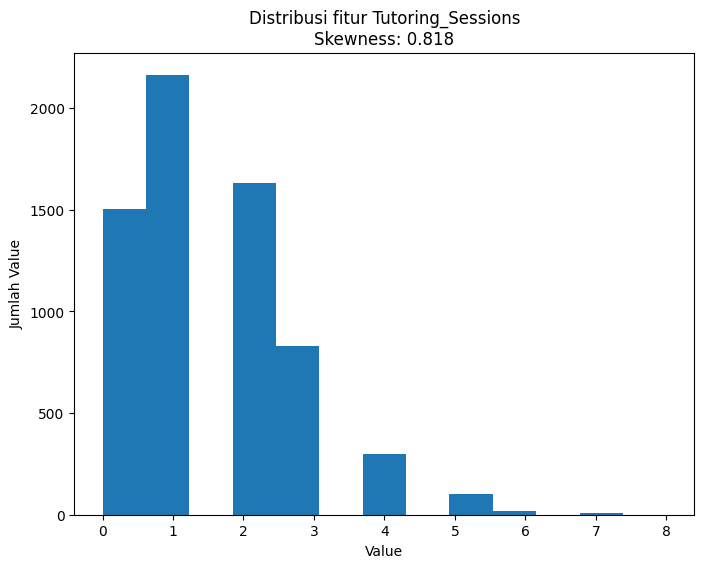

In [ ]:
#Tutoring_Sessions
import matplotlib.pyplot as plt
import numpy as np

ts = df['Tutoring_Sessions']
ts_skewness = ts.skew()
sturges_bin_ts = int(1 + np.log2(len(ts)))

plt.figure(figsize=(8, 6))
plt.hist(ts, bins=sturges_bin_ts)
plt.title(f"Distribusi fitur Tutoring_Sessions\nSkewness: {ts_skewness:.3f}")
plt.xlabel("Value")
plt.ylabel("Jumlah Value")
plt.show()


In [ ]:
Q1_ts = ts.quantile(0.25)
Q2_ts = ts.quantile(0.5)
Q3_ts = ts.quantile(0.75)

IQR_ts = Q3_ts - Q1_ts
lower_bound_ts = Q1_ts - 1.5 * IQR_ts
upper_bound_ts = Q3_ts + 2.0 * IQR_ts

In [ ]:
print(f'Median: {Q2_ts}')

Median: 1.0


In [ ]:
outliers_count_ts = df[(df['Tutoring_Sessions'] < lower_bound_ts) | (df['Tutoring_Sessions'] > upper_bound_ts)].shape[0]

print(f"-- Outlier Setelah Perubahan Pengali IQR --")
print(f"")
print(f"Jumlah Outlier: {outliers_count_ts}")
print(f"Persentase Outlier: {outliers_count_ts / df.shape[0] * 100}%")

-- Outlier Setelah Perubahan Pengali IQR --

Jumlah Outlier: 129
Persentase Outlier: 1.9652650822669104%


In [ ]:
df['Tutoring_Sessions_Imputed'] = df['Tutoring_Sessions'].apply(
    lambda x: Q2_ts if x < lower_bound_ts or x > upper_bound_ts else x
)

In [ ]:
df = df.drop("Tutoring_Sessions", axis=1)

In [ ]:
#Exam_Score
df = df[df['Exam_Score'] <= 100]

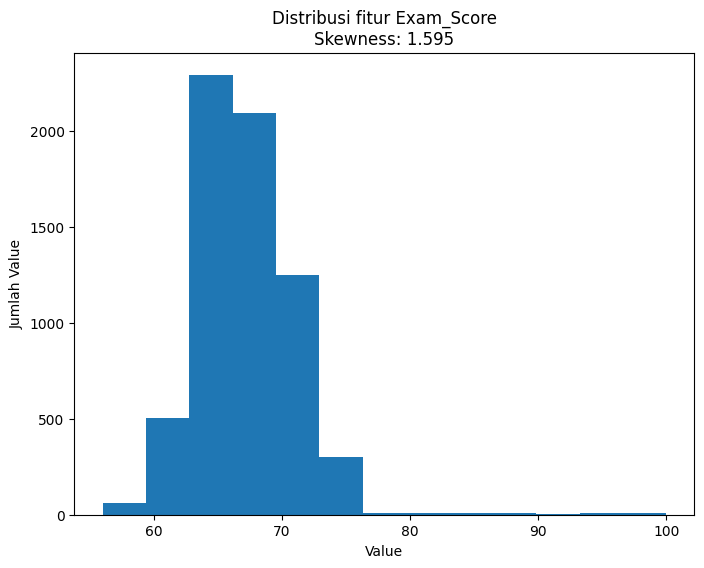

In [ ]:
es = df['Exam_Score']

es_skewness = es.skew()
sturges_bin_es = int(1 + np.log2(len(es)))

plt.figure(figsize=(8, 6))
plt.hist(es, bins=sturges_bin_es)
plt.title(f"Distribusi fitur Exam_Score\nSkewness: {es_skewness:.3f}")
plt.xlabel("Value")
plt.ylabel("Jumlah Value")
plt.show()


In [ ]:
Q1_es = es.quantile(0.25)
Q2_es = es.quantile(0.5)
Q3_es = es.quantile(0.75)

IQR_es = Q3_es - Q1_es
lower_bound_es = Q1_es - 1.5 * IQR_es
upper_bound_es = Q3_es + 2.5 * IQR_es

In [ ]:
print(f'Median kolom Exam_Score: {Q2_es}')

Median kolom Exam_Score: 67.0


In [ ]:
outliers_count_es = df[(df['Exam_Score'] < lower_bound_es) | (df['Exam_Score'] > upper_bound_es)].shape[0]

print(f"-- Outlier Setelah Perubahan Pengali IQR --")
print(f"")
print(f"Jumlah Outlier: {outliers_count_es}")
print(f"Persentase Outlier: {outliers_count_es / df.shape[0] * 100}%")

-- Outlier Setelah Perubahan Pengali IQR --

Jumlah Outlier: 68
Persentase Outlier: 1.0361115343592868%


In [ ]:
df['Exam_Score_Imputed'] = df['Exam_Score'].apply(
    lambda x: Q2_es if x < lower_bound_es or x > upper_bound_es else x
)

In [ ]:
df = df.drop("Exam_Score", axis=1)

2\. Data Transformation

In [ ]:
feature_col = df.drop(columns=['Exam_Score_Imputed'])
label_col = df[['Exam_Score_Imputed']]

In [ ]:
feature_col.head(5)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Family_Income,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Gender,Teacher_Quality_Index,Parental_Education_Level_Index,Distance_from_Home_Index,Tutoring_Sessions_Imputed
0,23,84,Low,High,No,7,73,Low,Yes,Low,Public,Positive,3,No,Male,2.0,1.0,1.0,0.0
1,19,64,Low,Medium,No,8,59,Low,Yes,Medium,Public,Negative,4,No,Female,2.0,2.0,2.0,2.0
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,Medium,Public,Neutral,4,No,Male,2.0,1.0,1.0,2.0
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,Medium,Public,Negative,4,No,Male,2.0,1.0,2.0,1.0
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,Medium,Public,Neutral,4,No,Female,3.0,2.0,1.0,3.0


In [ ]:
categorical_feature = feature_col[categorical_col]

In [ ]:
categorical_feature.head(5)

,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Motivation_Level,Internet_Access,Family_Income,School_Type,Peer_Influence,Learning_Disabilities,Gender
0,Low,High,No,Low,Yes,Low,Public,Positive,No,Male
1,Low,Medium,No,Low,Yes,Medium,Public,Negative,No,Female
2,Medium,Medium,Yes,Medium,Yes,Medium,Public,Neutral,No,Male
3,Low,Medium,Yes,Medium,Yes,Medium,Public,Negative,No,Male
4,Medium,Medium,Yes,Medium,Yes,Medium,Public,Neutral,No,Female


In [ ]:
ordinal = categorical_feature[['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level', 'Family_Income', 'Peer_Influence']]
nominal = categorical_feature[['Extracurricular_Activities', 'Internet_Access', 'School_Type', 'Learning_Disabilities', 'Gender']]

In [ ]:
#Ordinal
ordinal.head(5)

,Parental_Involvement,Access_to_Resources,Motivation_Level,Family_Income,Peer_Influence
0,Low,High,Low,Low,Positive
1,Low,Medium,Low,Medium,Negative
2,Medium,Medium,Medium,Medium,Neutral
3,Low,Medium,Medium,Medium,Negative
4,Medium,Medium,Medium,Medium,Neutral


In [ ]:
ordinal['Parental_Involvement_Index'] = ordinal['Parental_Involvement'].map({'Low': 1, 'Medium': 2, 'High': 3})
ordinal['Access_to_Resources_Index'] = ordinal['Access_to_Resources'].map({'Low': 1, 'Medium': 2, 'High': 3})
ordinal['Motivation_Level_Index'] = ordinal['Motivation_Level'].map({'Low': 1, 'Medium': 2, 'High': 3})
ordinal['Family_Income_Index'] = ordinal['Family_Income'].map({'Low': 1, 'Medium': 2, 'High': 3})
ordinal['Peer_Influence_Index'] = ordinal['Peer_Influence'].map({'Negative': 1, 'Neutral': 2, 'Positive': 3})

/tmp/ipython-input-1025003464.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ordinal['Parental_Involvement_Index'] = ordinal['Parental_Involvement'].map({'Low': 1, 'Medium': 2, 'High': 3})
/tmp/ipython-input-1025003464.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ordinal['Access_to_Resources_Index'] = ordinal['Access_to_Resources'].map({'Low': 1, 'Medium': 2, 'High': 3})
/tmp/ipython-input-1025003464.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

In [ ]:
ordinal = ordinal.drop(columns=["Parental_Involvement", "Access_to_Resources", "Motivation_Level", "Family_Income", "Peer_Influence"])

In [ ]:
ordinal['id'] = range(len(ordinal))

In [ ]:
ordinal.head(5)

,Parental_Involvement_Index,Access_to_Resources_Index,Motivation_Level_Index,Family_Income_Index,Peer_Influence_Index,id
0,1,3,1,1,3,0
1,1,2,1,2,1,1
2,2,2,2,2,2,2
3,1,2,2,2,1,3
4,2,2,2,2,2,4


In [ ]:
#Nominal
nominal.head(5)

,Extracurricular_Activities,Internet_Access,School_Type,Learning_Disabilities,Gender
0,No,Yes,Public,No,Male
1,No,Yes,Public,No,Female
2,Yes,Yes,Public,No,Male
3,Yes,Yes,Public,No,Male
4,Yes,Yes,Public,No,Female


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

label_encoders = {col: LabelEncoder() for col in nominal.columns}
onehot_encoder = ColumnTransformer(
    transformers=[(col, OneHotEncoder(), [col]) for col in nominal.columns],
    remainder='passthrough'
)

pipeline_nominal = Pipeline(steps=[
    ('label_encoders', FunctionTransformer(lambda X: pd.DataFrame(
        {col: label_encoders[col].fit_transform(X[col]) for col in X.columns},
        columns=X.columns))),
    ('onehot_encoder', onehot_encoder)
])

encoded_nominal = pipeline_nominal.fit_transform(nominal)

encoded_nominal_df = pd.DataFrame(encoded_nominal, columns=onehot_encoder.get_feature_names_out())

In [ ]:
encoded_nominal_df['id'] = range(len(encoded_nominal_df))

In [ ]:
encoded_nominal_df.head(5)

,Extracurricular_Activities__Extracurricular_Activities_0,Extracurricular_Activities__Extracurricular_Activities_1,Internet_Access__Internet_Access_0,Internet_Access__Internet_Access_1,School_Type__School_Type_0,School_Type__School_Type_1,Learning_Disabilities__Learning_Disabilities_0,Learning_Disabilities__Learning_Disabilities_1,Gender__Gender_0,Gender__Gender_1,id
0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0
1,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1
2,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,2
3,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,3
4,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,4


In [ ]:
encoded_nominal_df.dtypes

,0
Extracurricular_Activities__Extracurricular_Activities_0,float64
Extracurricular_Activities__Extracurricular_Activities_1,float64
Internet_Access__Internet_Access_0,float64
Internet_Access__Internet_Access_1,float64
School_Type__School_Type_0,float64
School_Type__School_Type_1,float64
Learning_Disabilities__Learning_Disabilities_0,float64
Learning_Disabilities__Learning_Disabilities_1,float64
Gender__Gender_0,float64
Gender__Gender_1,float64


In [ ]:
numerical_feature = feature_col[feature_col.columns.difference(categorical_col)]

In [ ]:
numerical_feature.loc[:, 'id'] = range(len(numerical_feature))

/tmp/ipython-input-853684688.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  numerical_feature.loc[:, 'id'] = range(len(numerical_feature))


In [ ]:
numerical_feature.head(5)

,Attendance,Distance_from_Home_Index,Hours_Studied,Parental_Education_Level_Index,Physical_Activity,Previous_Scores,Sleep_Hours,Teacher_Quality_Index,Tutoring_Sessions_Imputed,id
0,84,1.0,23,1.0,3,73,7,2.0,0.0,0
1,64,2.0,19,2.0,4,59,8,2.0,2.0,1
2,98,1.0,24,1.0,4,91,7,2.0,2.0,2
3,89,2.0,29,1.0,4,98,8,2.0,1.0,3
4,92,1.0,19,2.0,4,65,6,3.0,3.0,4


In [ ]:
numerical_feature.dtypes

,0
Attendance,int64
Distance_from_Home_Index,float64
Hours_Studied,int64
Parental_Education_Level_Index,float64
Physical_Activity,int64
Previous_Scores,int64
Sleep_Hours,int64
Teacher_Quality_Index,float64
Tutoring_Sessions_Imputed,float64
id,int64


In [ ]:
ordinal.head(5)

,Parental_Involvement_Index,Access_to_Resources_Index,Motivation_Level_Index,Family_Income_Index,Peer_Influence_Index,id
0,1,3,1,1,3,0
1,1,2,1,2,1,1
2,2,2,2,2,2,2
3,1,2,2,2,1,3
4,2,2,2,2,2,4


In [ ]:
ordinal.dtypes

,0
Parental_Involvement_Index,int64
Access_to_Resources_Index,int64
Motivation_Level_Index,int64
Family_Income_Index,int64
Peer_Influence_Index,int64
id,int64


In [ ]:
#Join Features
final_features = numerical_feature.merge(ordinal, on="id").merge(encoded_nominal_df, on="id")

final_features = final_features.drop("id", axis=1)

In [ ]:
final_features.head(5)

,Attendance,Distance_from_Home_Index,Hours_Studied,Parental_Education_Level_Index,Physical_Activity,Previous_Scores,Sleep_Hours,Teacher_Quality_Index,Tutoring_Sessions_Imputed,Parental_Involvement_Index,...,Extracurricular_Activities__Extracurricular_Activities_0,Extracurricular_Activities__Extracurricular_Activities_1,Internet_Access__Internet_Access_0,Internet_Access__Internet_Access_1,School_Type__School_Type_0,School_Type__School_Type_1,Learning_Disabilities__Learning_Disabilities_0,Learning_Disabilities__Learning_Disabilities_1,Gender__Gender_0,Gender__Gender_1
0,84,1.0,23,1.0,3,73,7,2.0,0.0,1,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
1,64,2.0,19,2.0,4,59,8,2.0,2.0,1,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
2,98,1.0,24,1.0,4,91,7,2.0,2.0,2,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
3,89,2.0,29,1.0,4,98,8,2.0,1.0,1,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
4,92,1.0,19,2.0,4,65,6,3.0,3.0,2,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0


In [ ]:
print(final_features.columns)

Index(['Attendance', 'Distance_from_Home_Index', 'Hours_Studied',
       'Parental_Education_Level_Index', 'Physical_Activity',
       'Previous_Scores', 'Sleep_Hours', 'Teacher_Quality_Index',
       'Tutoring_Sessions_Imputed', 'Parental_Involvement_Index',
       'Access_to_Resources_Index', 'Motivation_Level_Index',
       'Family_Income_Index', 'Peer_Influence_Index',
       'Extracurricular_Activities__Extracurricular_Activities_0',
       'Extracurricular_Activities__Extracurricular_Activities_1',
       'Internet_Access__Internet_Access_0',
       'Internet_Access__Internet_Access_1', 'School_Type__School_Type_0',
       'School_Type__School_Type_1',
       'Learning_Disabilities__Learning_Disabilities_0',
       'Learning_Disabilities__Learning_Disabilities_1', 'Gender__Gender_0',
       'Gender__Gender_1'],
      dtype='object')


In [ ]:
label_col.head(5)

,Exam_Score_Imputed
0,67.0
1,61.0
2,74.0
3,71.0
4,70.0


In [ ]:
from scipy.stats import spearmanr

for column in final_features.columns:
  correlation, _ = spearmanr(final_features[column], label_col.iloc[:, 0])
  print(f"Nilai korelasi spearman antara {column} dan Exam_Score: {correlation}")

Nilai korelasi spearman antara Attendance dan Exam_Score: 0.6803053382481992
Nilai korelasi spearman antara Distance_from_Home_Index dan Exam_Score: -0.09811780745774037
Nilai korelasi spearman antara Hours_Studied dan Exam_Score: 0.4725077000758842
Nilai korelasi spearman antara Parental_Education_Level_Index dan Exam_Score: 0.013623005228427893
Nilai korelasi spearman antara Physical_Activity dan Exam_Score: 0.028341028573571972
Nilai korelasi spearman antara Previous_Scores dan Exam_Score: 0.19170462661773763
Nilai korelasi spearman antara Sleep_Hours dan Exam_Score: -0.005059374628316405
Nilai korelasi spearman antara Teacher_Quality_Index dan Exam_Score: 0.07971216054108887
Nilai korelasi spearman antara Tutoring_Sessions_Imputed dan Exam_Score: 0.1429624111084269
Nilai korelasi spearman antara Parental_Involvement_Index dan Exam_Score: 0.17203850060855633
Nilai korelasi spearman antara Access_to_Resources_Index dan Exam_Score: 0.1866833572256627
Nilai korelasi spearman antara Mot

**D. EXPLORATORY DATA ANALYSIS**

---


In [ ]:
highest_spearman = final_features[['Attendance', 'Hours_Studied', 'Previous_Scores']]

highest_spearman.head(5)

,Attendance,Hours_Studied,Previous_Scores
0,84,23,73
1,64,19,59
2,98,24,91
3,89,29,98
4,92,19,65


-- Attendance --


Nilai korelasi spearman antara Attendance dan Exam_Score: 0.6803053382481992

        Attendance
count  6563.000000
mean     79.953223
std      11.539634
min      60.000000
25%      70.000000
50%      80.000000
75%      90.000000
max     100.000000



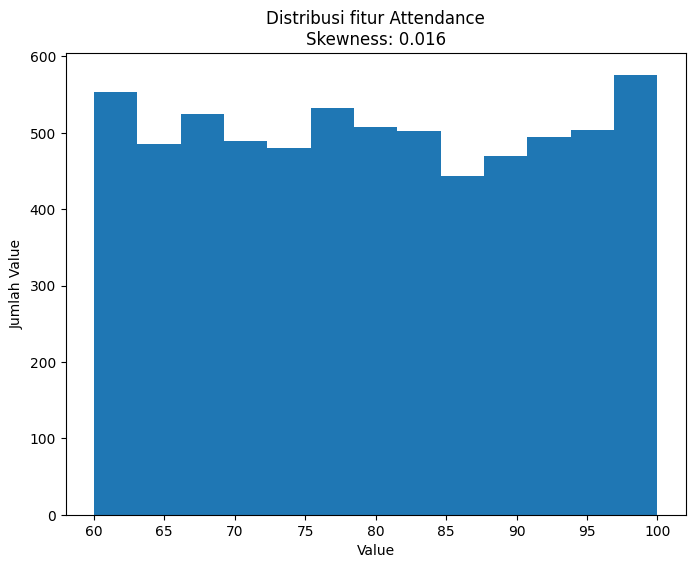

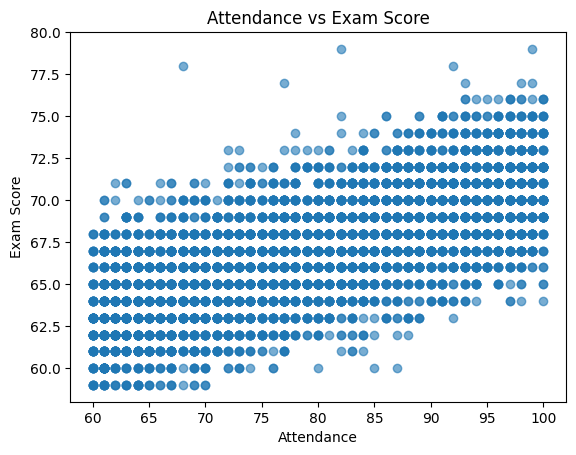


Nilai Korelasi Pearson antara Attendance dan Exam Score: 0.6738817112215895

-- Hours_Studied --


Nilai korelasi spearman antara Hours_Studied dan Exam_Score: 0.4725077000758842

       Hours_Studied
count    6563.000000
mean       19.968155
std         5.828107
min         4.000000
25%        16.000000
50%        20.000000
75%        24.000000
max        36.000000



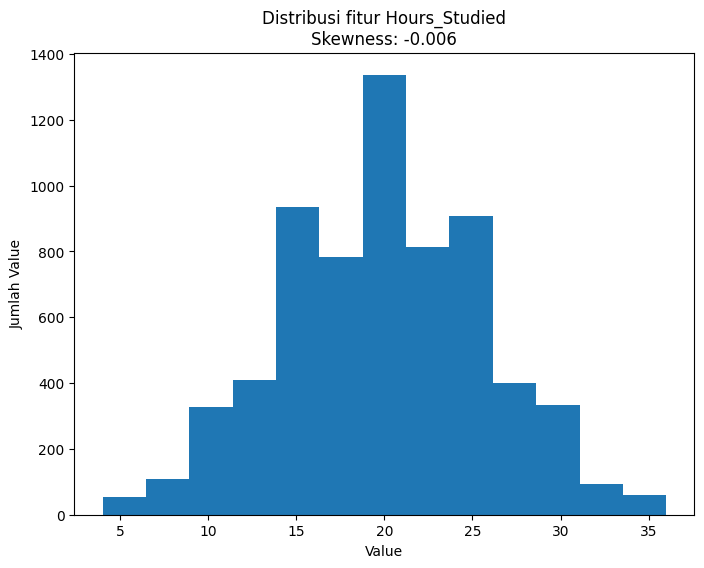

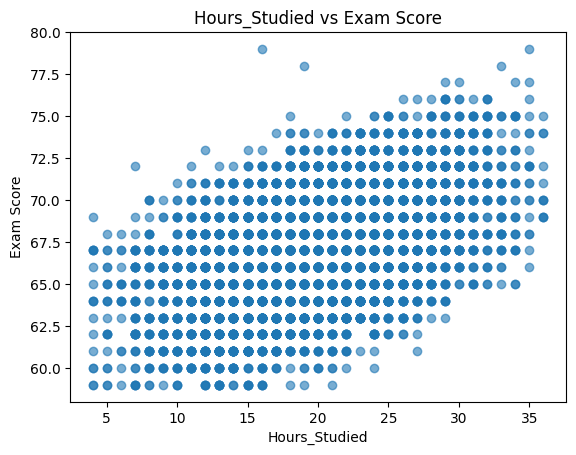


Nilai Korelasi Pearson antara Hours_Studied dan Exam Score: 0.4963315959707484

-- Previous_Scores --


Nilai korelasi spearman antara Previous_Scores dan Exam_Score: 0.19170462661773763

       Previous_Scores
count      6563.000000
mean         75.079080
std          14.402305
min          50.000000
25%          63.000000
50%          75.000000
75%          88.000000
max         100.000000



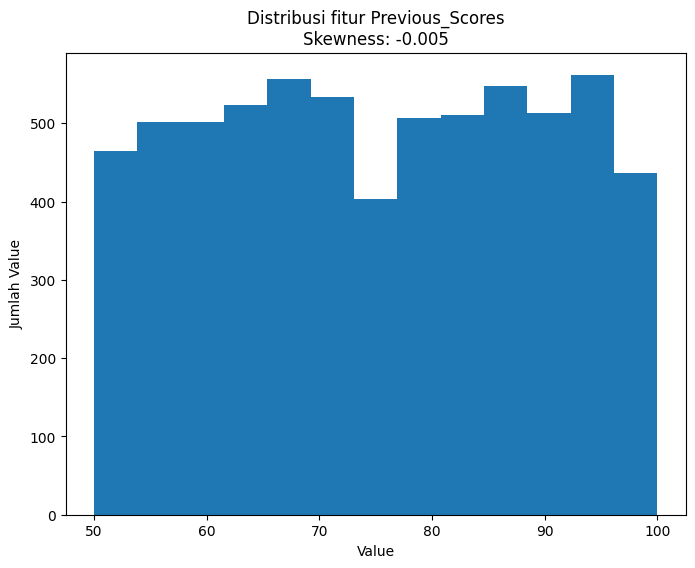

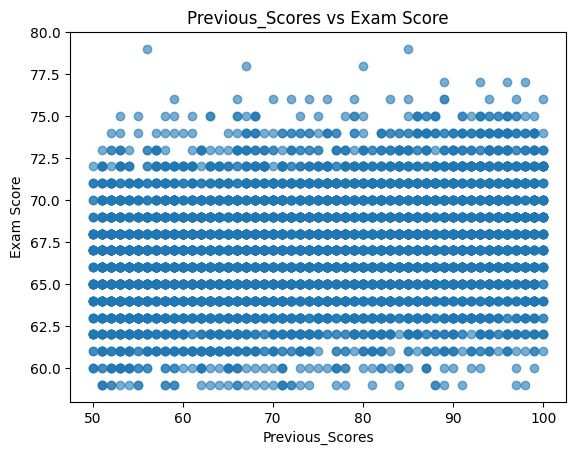


Nilai Korelasi Pearson antara Previous_Scores dan Exam Score: 0.1979492105458785



In [ ]:
from scipy.stats import pearsonr

for column in highest_spearman.columns:
  print(f"-- {column} --")
  print(f"")
  print(f"")
  correlation, _ = spearmanr(final_features[column], label_col.iloc[:, 0])
  print(f"Nilai korelasi spearman antara {column} dan Exam_Score: {correlation}")
  print(f"")
  print(final_features[[column]].describe())
  print(f"")
  plt.figure(figsize=(8, 6))
  plt.hist(final_features[column], bins=int(1 + np.log2(len(final_features[column]))))
  plt.title(f"Distribusi fitur {column}\nSkewness: {final_features[column].skew():.3f}")
  plt.xlabel("Value")
  plt.ylabel("Jumlah Value")
  plt.show()
  print(f"")
  plt.scatter(final_features[column], label_col.iloc[:, 0], alpha=0.6)
  plt.xlabel(f'{column}')
  plt.ylabel('Exam Score')
  plt.title(f'{column} vs Exam Score')
  plt.show()
  print(f"")
  correlation, p_value = pearsonr(final_features[column], label_col.iloc[:, 0])
  print(f"Nilai Korelasi Pearson antara {column} dan Exam Score: {correlation}")
  print(f"")

In [ ]:
correlation, p_value = pearsonr(final_features['Attendance'], final_features['Hours_Studied'])
print(f"Nilai Korelasi Pearson antara Attendance dan Hours Studied: {correlation}")
correlation, p_value = pearsonr(final_features['Attendance'], final_features['Previous_Scores'])
print(f"Nilai Korelasi Pearson antara Attendance dan Previous Scores: {correlation}")
correlation, p_value = pearsonr(final_features['Previous_Scores'], final_features['Hours_Studied'])
print(f"Nilai Korelasi Pearson antara Previous Scores dan Hours Studied: {correlation}")

Nilai Korelasi Pearson antara Attendance dan Hours Studied: -0.011299627299548837
Nilai Korelasi Pearson antara Attendance dan Previous Scores: -0.02001098935169326
Nilai Korelasi Pearson antara Previous Scores dan Hours Studied: 0.019443505785703113


**F. MODELLING**

---


In [ ]:
x = highest_spearman
y = label_col

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(x_train, y_train.values.ravel())

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = model.predict(x_test)

**G. EVALUASI MODEL**

---

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error (MAE): {mae}')

mape = mean_absolute_percentage_error(y_test, y_pred)
print(f'Mean Absolute Percentage Error (MAPE): {mape * 100}%')

r2 = r2_score(y_test, y_pred)
print(f'R^2 Score: {r2}')

Mean Absolute Error (MAE): 1.4833955923064832
Mean Absolute Percentage Error (MAPE): 2.215947711110082%
R^2 Score: 0.6659528178303228


In [ ]:
import joblib

joblib.dump(model, "model.pkl")
print("Model saved!")

Model saved!
